# Morphing study

This notebook examines the following:
$$
u(x\mid \theta)\equiv \nu(\theta)\,p(x\mid\theta)=\sum_{i=1}^{N_{\rm basis}} w_i(\theta)\,u_i(x),\qquad
u_i(x)\equiv \nu(\theta_i)\,p(x\mid\theta_i),
$$
into a **CFM/CNF** workflow where each $u_i(x)$ is learned by a flow (trained with flow matching), and the **analytic morphing weights** $w_i(\theta)$ are used at inference time.

$w_i(\theta)$ can be **negative** (Lagrange-style morphing). That means $u(x\mid\theta)$ is a **signed linear combination** of *positive* densities $u_i(x)$, but physics guarantees $u(x\mid\theta)\ge 0$ in the valid region. Numerically, must evaluate the signed sum stably.


In [30]:
import numpy as np
import torch

torch.set_default_dtype(torch.float32)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cpu


## Morphing weights

We use the monomial basis
$$
b(\theta)=\big[\kappa'^2\cos^2\alpha,\;\kappa'\cos\alpha,\;\kappa'^2\sin^2\alpha,\;\kappa'\sin\alpha,\;\kappa'^2\cos\alpha\sin\alpha,\;1\big],
$$
and the fixed inverse morphing matrix $G^{-1}$ to obtain
$$
w(\theta)=b(\theta)^\top G^{-1}.
$$


In [31]:
class MorphingWeights(torch.nn.Module):
    def __init__(self, basis_points):
        super().__init__()
        basis_points = np.asarray(basis_points, dtype=float)
        
        G = np.array([
            [
                
             k**2*np.cos(a)**2, 
             k*np.cos(a), 
             k**2*np.sin(a)**2,
             k*np.sin(a), 
             k**2*np.cos(a)*np.sin(a), 
             1.0,
             ]
            
            for k,a in basis_points
        ], dtype=float)
        
        
        G_inv = np.linalg.inv(G) if G.shape[0]==G.shape[1] else np.linalg.pinv(G)
        self.register_buffer("G_inv", torch.tensor(G_inv, dtype=torch.float32))  # [6,6]

    @staticmethod
    def monomials(kappa, alpha):
        
        kappa = torch.as_tensor(kappa)
        alpha = torch.as_tensor(alpha)
        c, s = torch.cos(alpha), torch.sin(alpha)
        
        return torch.stack([kappa**2*c**2, 
                            kappa*c, 
                            kappa**2*s**2,
                            kappa*s, 
                            kappa**2*c*s, 
                            torch.ones_like(kappa)], dim=-1)

    def forward(self, kappa, alpha):
        b = self.monomials(kappa, alpha) # [...,6]
        w = b @ self.G_inv
        return w

basis_points = [
    (1.0, 0.0),
    (1.0, np.pi/2),
    (1.0, np.pi/4),
    (1.5, np.pi/6),
    (0.5, np.pi/3),
    (1.0, np.pi/8),
]
W = MorphingWeights(basis_points).to(device)

# quick sanity check (weights can be negative)
kappa = torch.tensor([1.0], dtype=torch.float32, device=device)
alpha = torch.tensor([np.radians(10.0)], dtype=torch.float32, device=device)
print("w(theta):", W(kappa, alpha))


w(theta): tensor([[ 0.3939,  0.0267, -0.2128, -0.0126, -0.0210,  0.8258]])


## Stable signed log-sum-exp

Given per-basis log-unnormalised densities $\log u_i(x)$ and weights $w_i(\theta)$, we need
$$
u(x\mid\theta)=\sum_i w_i(\theta)\,\exp(\log u_i(x)).
$$
We compute positive and negative parts:
$$
u = u_+ - u_-,\qquad
u_+ = \sum_{i:w_i>0} w_i e^{\log u_i},\quad
u_- = \sum_{i:w_i<0} |w_i| e^{\log u_i}.
$$
Then $\log u = \log(u_+ - u_-)$ requires $u_+>u_-$.


In [32]:
def _logsumexp_weighted(log_u, w, eps=1e-30):
    """
    log_u: [B, K] log u_i(x)
    w:     [B, K] nonnegative weights
    returns: [B] log sum_i w_i * exp(log_u_i)
    """
    w = torch.clamp(w, min=0.0)
    log_w = torch.log(w + eps)
    return torch.logsumexp(log_u + log_w, dim=-1)

def signed_logsumexp(log_u, w, eps=1e-30):
    """
    Computes log( sum_i w_i * exp(log_u_i) ) with signed w_i.
    Returns:
      log_abs: [B] log |sum|
      sign:    [B] in {-1,+1}
      valid:   [B] True if result is strictly positive (sign=+1)
    """
    w_pos = torch.clamp(w, min=0.0)
    w_neg = torch.clamp(-w, min=0.0)

    log_pos = _logsumexp_weighted(log_u, w_pos, eps=eps)  # log u_+
    log_neg = _logsumexp_weighted(log_u, w_neg, eps=eps)  # log u_-

    diff = log_neg - log_pos
    valid = diff < 0

    log_abs = torch.empty_like(log_pos)
    log_abs[valid] = log_pos[valid] + torch.log1p(-torch.exp(diff[valid]))
    log_abs[~valid] = log_pos[~valid]  # placeholder, caller should mask

    sign = torch.ones_like(log_pos)
    sign[~valid] = -1.0
    return log_abs, sign, valid


## Flow matching model interface

For each basis point $i$, train a flow using a flow-matching objective.

- sampling: $z\sim\mathcal N(0,I)\mapsto x$ (forward ODE),
- density evaluation: $\log p_i(x)$ (backward ODE + divergence integral).


## Combine learned basis densities with morphing weights

Evaluate $\log p_i(x)$ for each basis flow and you know $\log \nu_i$ (expected yield at basis point). Define
$$
\log u_i(x)=\log\nu_i+\log p_i(x).
$$
Then the morphing unnormalized density is
$$
u(x\mid\theta)=\sum_i w_i(\theta)\,u_i(x).
$$

A convenient normalization in the same morphing approximation is
$$
\nu(\theta)\approx \sum_i w_i(\theta)\,\nu_i,
$$
so that
$$
\log p(x\mid\theta)=\log u(x\mid\theta)-\log \nu(\theta).
$$


In [33]:
def log_p_theta_from_basis(log_p_basis, log_nu_basis, w_theta, eps=1e-30):
    """
    log_p_basis:  [B,K]  log p_i(x) from learned flows
    log_nu_basis: [K]    log nu_i
    w_theta:      [B,K]  morphing weights at theta (signed)
    returns:
      log_p_theta: [B] log p(x|theta) (=-inf where invalid)
      valid:       [B] mask of valid events (positive combination)
    """
    log_u = log_p_basis + log_nu_basis[None, :]          # [B,K]
    log_u_theta, sign_u, valid_u = signed_logsumexp(log_u, w_theta, eps=eps)

    log_nu_theta, sign_nu, valid_nu = signed_logsumexp(
        log_nu_basis[None, :].expand_as(log_p_basis),
        w_theta,
        eps=eps,
    )

    valid = valid_u & valid_nu & (sign_u > 0) & (sign_nu > 0)

    log_p = torch.full_like(log_u_theta, -torch.inf)
    log_p[valid] = log_u_theta[valid] - log_nu_theta[valid]
    return log_p, valid


## Score w.r.t. $(\kappa',\alpha)$ from analytic weights

Because $u_i(x)$ do not depend on $\theta$, all $\theta$-dependence is in $w_i(\theta)$ (and $\nu(\theta)$). You get scores by differentiating through the weights:
$$
\nabla_\theta \log p(x\mid\theta)=
\frac{\sum_i (\nabla_\theta w_i(\theta))\,u_i(x)}{\sum_i w_i(\theta)\,u_i(x)}
-\nabla_\theta\log \nu(\theta).
$$


In [34]:
def score_theta_from_basis(u_basis, w_theta, dw_dtheta, nu_theta, dnu_dtheta):
    """
    u_basis:   [B,K]    u_i(x)=nu_i * p_i(x)  (linear space)
    w_theta:   [B,K]
    dw_dtheta: [B,K,2]  derivatives wrt (kappa, alpha)
    nu_theta:  [B]
    dnu_dtheta:[B,2]
    returns:
      score: [B,2]  grad_theta log p(x|theta)
    """
    num = torch.einsum("bk,bkq->bq", u_basis, dw_dtheta)      # [B,2]
    den = torch.einsum("bk,bk->b",  u_basis, w_theta)         # [B]
    term1 = num / den[:, None]
    term2 = dnu_dtheta / nu_theta[:, None]
    return term1 - term2


## Train per-basis density models

For each of the $K$ basis points we train an independent density model. Two methods, kept architecturally identical for a fair comparison:

- **FM (Flow Matching):** one velocity head per basis, trained against the linear-interpolant velocity target.
- **Bridge matching:** one velocity head and one score head per basis, trained jointly against the Brownian-bridge velocity / score targets. Both heads share `(t, z)` draws per step so they regress against the same bridge realisation.

Per-basis nets (rather than one shared network keyed by a basis embedding) avoid splitting capacity across the $K$ basis modes — this matters even on this toy. The bridge training additionally clamps `t` to `[bridge_train_eps, 1 - bridge_train_eps]` because the bridge velocity MSE target has noise variance `~1/min(t, 1-t)`; without the clamp the loss is dominated by endpoint noise and the learned velocity acquires a constant downward log-density bias.


x_train: (4800, 2) k_train: (4800,) K: 6


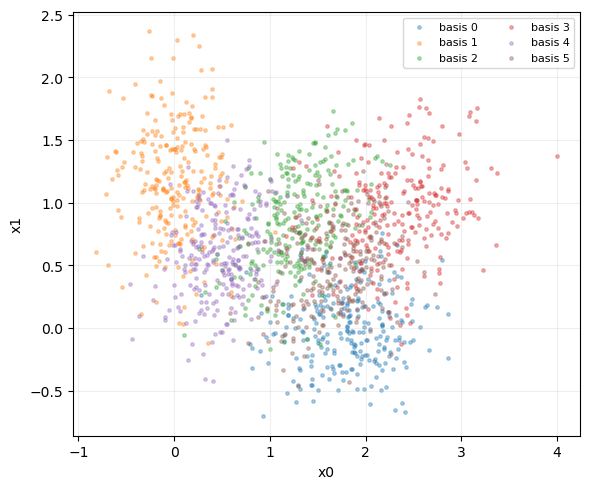

In [35]:
import matplotlib.pyplot as plt
from torch.distributions import MultivariateNormal

import nami

# Training data: K independent 2D Gaussians, one per basis point.
# Each is rotated/scaled by (kappa, alpha) so the basis spans a meaningful
# range of shapes. We sample n_train_per_basis points per basis and tag
# every sample with its basis index k for downstream conditioning.

K = len(basis_points)
x_dim = 2

CFG = {
    "n_train_per_basis": 800,
    "batch_size": 256,        # per-basis batch (each step trains all K nets)
    "fm_steps": 2000,
    "bridge_steps": 2000,
    "solver_steps": 32,
    "eval_samples": 1024,
    "mc_repeats": 1,
    # Clamp t away from {0,1} in *training* the bridge. The bridge velocity
    # target has noise variance ~1/min(t,1-t), so MSE gradients are
    # dominated by noise near the endpoints; this keeps training stable.
    "bridge_train_eps": 0.05,
}


def make_basis_dist(kappa, alpha, *, device=device):
    """Toy basis density: 2D Gaussian rotated by alpha and scaled by kappa."""
    kappa_t = torch.tensor(float(kappa), device=device)
    alpha_t = torch.tensor(float(alpha), device=device)
    c, s = torch.cos(alpha_t), torch.sin(alpha_t)

    mean = torch.stack([1.8 * kappa_t * c, 1.2 * kappa_t * s])
    rot = torch.stack([
        torch.stack([c, -s]),
        torch.stack([s, c]),
    ])
    scale_1 = 0.25 + 0.15 * kappa_t
    scale_2 = 0.15 + 0.10 * kappa_t
    cov_local = torch.diag(torch.stack([scale_1**2, scale_2**2]))
    cov = rot @ cov_local @ rot.T + 0.03 * torch.eye(x_dim, device=device)
    return MultivariateNormal(mean, cov)


basis_dists = [make_basis_dist(kappa, alpha) for (kappa, alpha) in basis_points]
log_nu_basis = torch.zeros(K, device=device)  # demo choice: nu_i = 1 for all basis points

# Materialise training samples: x_train rows are concatenated per-basis batches,
# k_train carries the basis index for each row.
x_chunks, k_chunks = [], []
for i, dist in enumerate(basis_dists):
    xi = dist.sample((CFG["n_train_per_basis"],))
    ki = torch.full((CFG["n_train_per_basis"],), i, dtype=torch.long, device=device)
    x_chunks.append(xi)
    k_chunks.append(ki)

x_train = torch.cat(x_chunks, dim=0)
k_train = torch.cat(k_chunks, dim=0)
# Per-basis index lists, used by the per-basis training loops.
basis_indices = [torch.where(k_train == i)[0] for i in range(K)]

print("x_train:", tuple(x_train.shape), "k_train:", tuple(k_train.shape), "K:", K)

fig, ax = plt.subplots(figsize=(6, 5))
for i in range(K):
    pts = x_train[basis_indices[i]][:250].detach().cpu()
    ax.scatter(pts[:, 0], pts[:, 1], s=6, alpha=0.35, label=f"basis {i}")
ax.set_xlabel("x0")
ax.set_ylabel("x1")
ax.grid(alpha=0.2)
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()


In [36]:
class PerBasisField(torch.nn.Module):
    """Small unconditional vector field f(x, t) -> R^x_dim.

    One instance per basis index. Used as a velocity head or a score head;
    the only difference between the two roles is what loss target is used
    at training time. Keeping the architecture identical across roles makes
    the FM-vs-bridge comparison fair.
    """

    def __init__(self, x_dim: int, hidden: int = 128, layers: int = 4):
        super().__init__()
        seq = [torch.nn.Linear(x_dim + 1, hidden), torch.nn.SiLU()]
        for _ in range(layers - 2):
            seq += [torch.nn.Linear(hidden, hidden), torch.nn.SiLU()]
        seq += [torch.nn.Linear(hidden, x_dim)]
        self.net = torch.nn.Sequential(*seq)

    @property
    def event_ndim(self) -> int:
        return 1

    def forward(self, x: torch.Tensor, t: torch.Tensor, c=None) -> torch.Tensor:
        # nami passes time as either a scalar, shape [B], or shape [B, 1].
        # Normalise to [..., 1] and broadcast across the batch dims.
        lead = x.shape[:-1]
        if t.ndim == len(lead) + 1 and t.shape[-1] == 1:
            t = t.squeeze(-1)
        if t.ndim == 0:
            t = t.expand(lead)
        elif tuple(t.shape) != tuple(lead):
            t = t.expand(lead)
        t = t.unsqueeze(-1)
        return self.net(torch.cat([x, t], dim=-1))


In [37]:
# Flow Matching: one independent velocity head per basis.
#
# For each basis i we regress against the linear-interpolant target with
# velocity_prediction(). Because the K networks are independent, training
# them in lockstep (one combined optimiser, K independent loss terms summed)
# is equivalent to training K separate models — gradients only flow into the
# corresponding network's parameters.

fm_fields = torch.nn.ModuleList(
    [PerBasisField(x_dim=x_dim) for _ in range(K)]
).to(device)

fm_opt = torch.optim.Adam(fm_fields.parameters(), lr=2e-3)
fm_sched = torch.optim.lr_scheduler.CosineAnnealingLR(
    fm_opt, T_max=CFG["fm_steps"], eta_min=1e-5
)

fm_interpolant = nami.LinearInterpolant()
fm_param = nami.velocity_prediction()
fm_losses = []

log_every = max(1, CFG["fm_steps"] // 10)
for step in range(1, CFG["fm_steps"] + 1):
    total_loss = 0.0
    fm_opt.zero_grad()
    for i in range(K):
        # Sample a per-basis batch.
        idx = basis_indices[i][
            torch.randint(0, basis_indices[i].numel(), (CFG["batch_size"],), device=device)
        ]
        xb = x_train[idx]
        x_noise = torch.randn_like(xb)

        loss_i = nami.regression_loss(
            fm_fields[i],
            x_noise=x_noise,
            x_data=xb,
            interpolant=fm_interpolant,
            parameterization=fm_param,
        )
        # Each loss_i only touches fm_fields[i]'s params, so backwarding the
        # sum is the same as K independent backward passes.
        (loss_i / K).backward()
        total_loss += loss_i.item()

    fm_opt.step()
    fm_sched.step()

    fm_losses.append(total_loss / K)
    if step % log_every == 0 or step == 1:
        print(
            f"FM step {step:5d} | mean per-basis loss {total_loss / K:.4f} "
            f"| lr {fm_sched.get_last_lr()[0]:.2e}"
        )


FM step     1 | mean per-basis loss 2.5887 | lr 2.00e-03
FM step   200 | mean per-basis loss 0.6478 | lr 1.95e-03
FM step   400 | mean per-basis loss 0.6087 | lr 1.81e-03
FM step   600 | mean per-basis loss 0.6079 | lr 1.59e-03
FM step   800 | mean per-basis loss 0.6127 | lr 1.31e-03
FM step  1000 | mean per-basis loss 0.6111 | lr 1.00e-03
FM step  1200 | mean per-basis loss 0.5804 | lr 6.98e-04
FM step  1400 | mean per-basis loss 0.6090 | lr 4.20e-04
FM step  1600 | mean per-basis loss 0.5969 | lr 2.00e-04
FM step  1800 | mean per-basis loss 0.5838 | lr 5.87e-05
FM step  2000 | mean per-basis loss 0.5829 | lr 1.00e-05


Bridge step     1 | mean loss 11.8826 (flow 3.6328, score 8.2498) | lr 2.00e-03
Bridge step   200 | mean loss 7.4759 (flow 1.7780, score 5.6979) | lr 1.95e-03
Bridge step   400 | mean loss 7.1000 (flow 1.6739, score 5.4261) | lr 1.81e-03
Bridge step   600 | mean loss 7.7573 (flow 1.7817, score 5.9756) | lr 1.59e-03
Bridge step   800 | mean loss 7.4855 (flow 1.7727, score 5.7127) | lr 1.31e-03
Bridge step  1000 | mean loss 7.4647 (flow 1.8029, score 5.6618) | lr 1.00e-03
Bridge step  1200 | mean loss 7.3102 (flow 1.7062, score 5.6040) | lr 6.98e-04
Bridge step  1400 | mean loss 7.2301 (flow 1.7388, score 5.4913) | lr 4.20e-04
Bridge step  1600 | mean loss 7.3003 (flow 1.6780, score 5.6223) | lr 2.00e-04
Bridge step  1800 | mean loss 6.7890 (flow 1.6597, score 5.1293) | lr 5.87e-05
Bridge step  2000 | mean loss 7.0891 (flow 1.6799, score 5.4092) | lr 1.00e-05


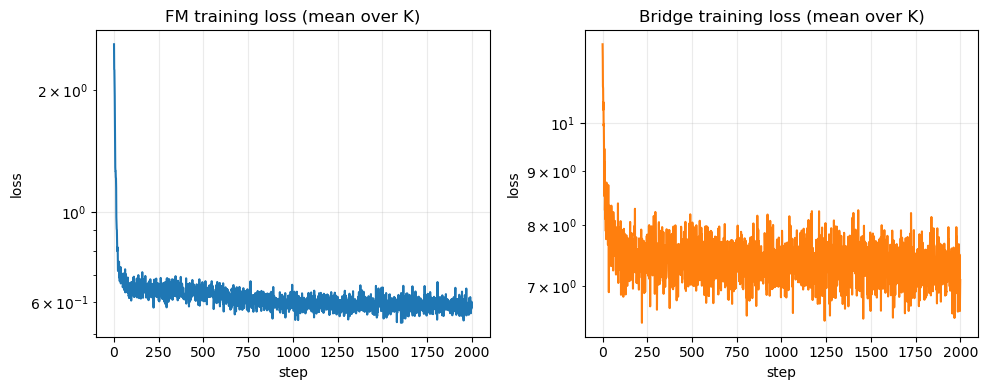

In [38]:
# Bridge matching: one independent velocity + one score head per basis.
#
# Two important details:
# 1. Per-basis nets, same as FM — no shared capacity confounding the
#    FM-vs-bridge comparison.
# 2. t is clamped to [bridge_train_eps, 1 - bridge_train_eps] (not the
#    interpolant's tiny default eps=1e-5). Near t in {0,1}, the bridge
#    velocity target's noise term has variance ~1/min(t, 1-t), which
#    overwhelms MSE gradients and biases the learned velocity. Clamping
#    keeps the loss signal informative across the whole training interval.
# 3. Flow and score share the same (t, z) draw per step so they regress
#    against the *same* bridge realisation — mirrors the upstream
#    nami.losses.bridge.bridge_matching_loss design.

bridge_flows = torch.nn.ModuleList(
    [PerBasisField(x_dim=x_dim) for _ in range(K)]
).to(device)
bridge_scores = torch.nn.ModuleList(
    [PerBasisField(x_dim=x_dim) for _ in range(K)]
).to(device)

bridge_opt = torch.optim.Adam(
    list(bridge_flows.parameters()) + list(bridge_scores.parameters()),
    lr=2e-3,
)
bridge_sched = torch.optim.lr_scheduler.CosineAnnealingLR(
    bridge_opt, T_max=CFG["bridge_steps"], eta_min=1e-5
)

bridge_interpolant = nami.BrownianBridgeInterpolant(sigma=1.0)
flow_param = nami.Parameterization(target=nami.Velocity())
score_param = nami.Parameterization(target=nami.Score())
eps_train = CFG["bridge_train_eps"]
bridge_losses = []

log_every = max(1, CFG["bridge_steps"] // 10)
for step in range(1, CFG["bridge_steps"] + 1):
    total_flow, total_score = 0.0, 0.0
    bridge_opt.zero_grad()
    for i in range(K):
        idx = basis_indices[i][
            torch.randint(0, basis_indices[i].numel(), (CFG["batch_size"],), device=device)
        ]
        x_data = x_train[idx]
        x_noise = torch.randn_like(x_data)
        # Shared (t, z) for the two heads; clamp t well away from {0,1}.
        t = torch.rand(x_data.shape[0], device=device).clamp(eps_train, 1.0 - eps_train)
        z = torch.randn_like(x_data)

        flow_loss = nami.regression_loss(
            bridge_flows[i],
            x_noise=x_noise, x_data=x_data, t=t, z=z,
            interpolant=bridge_interpolant,
            parameterization=flow_param,
            eps_t=eps_train,
        )
        score_loss = nami.regression_loss(
            bridge_scores[i],
            x_noise=x_noise, x_data=x_data, t=t, z=z,
            interpolant=bridge_interpolant,
            parameterization=score_param,
            eps_t=eps_train,
        )
        ((flow_loss + score_loss) / K).backward()
        total_flow += flow_loss.item()
        total_score += score_loss.item()

    bridge_opt.step()
    bridge_sched.step()

    bridge_losses.append((total_flow + total_score) / K)
    if step % log_every == 0 or step == 1:
        print(
            f"Bridge step {step:5d} | mean loss {(total_flow + total_score)/K:.4f} "
            f"(flow {total_flow/K:.4f}, score {total_score/K:.4f}) "
            f"| lr {bridge_sched.get_last_lr()[0]:.2e}"
        )

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(fm_losses)
axes[0].set_title("FM training loss (mean over K)")
axes[0].set_xlabel("step")
axes[0].set_ylabel("loss")
axes[0].set_yscale("log")
axes[0].grid(alpha=0.25)

axes[1].plot(bridge_losses, color="tab:orange")
axes[1].set_title("Bridge training loss (mean over K)")
axes[1].set_xlabel("step")
axes[1].set_ylabel("loss")
axes[1].set_yscale("log")
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()


In [ ]:
# Inference: turn trained per-basis nets into nami processes that can sample
# and (more importantly here) evaluate log p_i(x).

BASE_DIST = nami.StandardNormal(event_shape=(x_dim,), device=device)


def make_processes(fields, *, solver_steps: int = 32):
    """Build one FlowMatchingProcess per basis from a list of velocity nets."""
    processes = []
    for f in fields:
        fm = nami.FlowMatching(
            field=f,
            base=BASE_DIST,
            solver=nami.RK4(steps=solver_steps),
            t0=0.0,  # noise side
            t1=1.0,  # data side
        )
        processes.append(fm(None))
    return processes


def log_p_basis_from_processes(processes, x, *, estimator, batch_size=128, mc_repeats=1):
    """Return [B, K] matrix of per-basis log p_i(x), optionally MC-averaged."""
    cols = []
    for process in processes:
        mc_vals = []
        for _ in range(mc_repeats):
            vals = []
            for start in range(0, x.shape[0], batch_size):
                vals.append(process.log_prob(x[start : start + batch_size], estimator=estimator))
            mc_vals.append(torch.cat(vals, dim=0))
        cols.append(torch.stack(mc_vals, dim=0).mean(dim=0))
    return torch.stack(cols, dim=-1)


fm_processes = make_processes(fm_fields, solver_steps=CFG["solver_steps"])
bridge_processes = make_processes(bridge_flows, solver_steps=CFG["solver_steps"])
div_estimator = nami.HutchinsonDivergence(probe="rademacher")


     FM | valid_frac=0.997 | NLL(model)=1.073 | NLL(true)=0.928 | mean(logp_model-logp_true)=-0.145
 Bridge | valid_frac=0.998 | NLL(model)=1.102 | NLL(true)=0.932 | mean(logp_model-logp_true)=-0.170


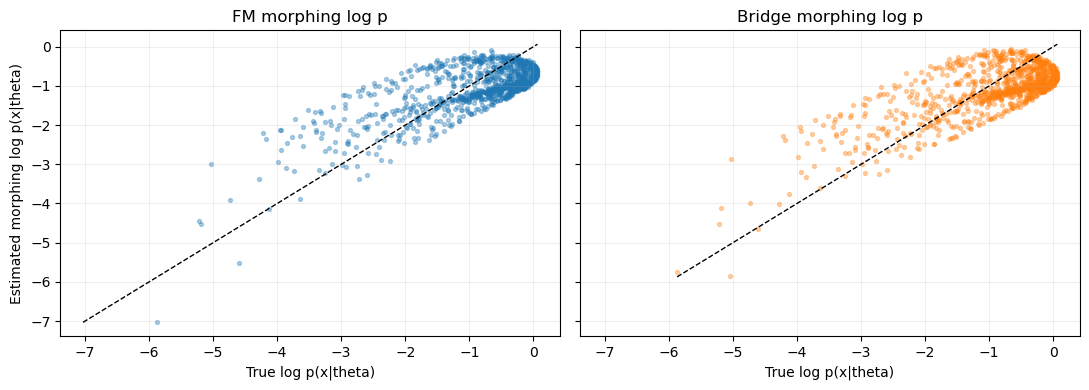

In [47]:
# Off-basis evaluation: pick a theta NOT in the basis, sample from the
# true distribution at that theta, and compare:
#   - true log p(x|theta) from the analytic Gaussian, and
#   - morphing log p(x|theta) reconstructed from learned per-basis log p_i.
#
# Memory note: Hutchinson uses torch.enable_grad() internally for its vjp,
# so wrapping the outer eval in torch.no_grad() releases the per-step
# autograd graph after each divergence estimate. detach() the [B, K] log_p
# tensors to drop any residual graph references; gc + cuda.empty_cache
# between FM and bridge sweeps actually frees the allocator blocks.

import gc

theta_eval = (1.2, float(np.deg2rad(35.0)))
dist_eval = make_basis_dist(*theta_eval)

with torch.no_grad():
    x_eval = dist_eval.sample((CFG["eval_samples"],))
    true_log_p = dist_eval.log_prob(x_eval)

    kappa_eval = torch.full((x_eval.shape[0],), theta_eval[0], device=device)
    alpha_eval = torch.full((x_eval.shape[0],), theta_eval[1], device=device)
    w_eval = W(kappa_eval, alpha_eval)

    log_p_basis_fm = log_p_basis_from_processes(
        fm_processes, x_eval,
        estimator=div_estimator, batch_size=128, mc_repeats=CFG["mc_repeats"],
    ).detach()
    if device.type == "cuda":
        torch.cuda.empty_cache()
    gc.collect()

    log_p_basis_bridge = log_p_basis_from_processes(
        bridge_processes, x_eval,
        estimator=div_estimator, batch_size=128, mc_repeats=CFG["mc_repeats"],
    ).detach()
    if device.type == "cuda":
        torch.cuda.empty_cache()
    gc.collect()

    log_p_theta_fm, valid_fm = log_p_theta_from_basis(log_p_basis_fm, log_nu_basis, w_eval)
    log_p_theta_bridge, valid_bridge = log_p_theta_from_basis(
        log_p_basis_bridge, log_nu_basis, w_eval,
    )


def summarize(name, log_p_model, valid):
    valid_frac = valid.float().mean().item()
    if valid.any():
        nll_model = -log_p_model[valid].mean().item()
        nll_true = -true_log_p[valid].mean().item()
        mean_delta = (log_p_model[valid] - true_log_p[valid]).mean().item()
    else:
        nll_model = nll_true = mean_delta = float("nan")
    print(
        f"{name:>7s} | valid_frac={valid_frac:.3f} | "
        f"NLL(model)={nll_model:.3f} | NLL(true)={nll_true:.3f} | "
        f"mean(logp_model-logp_true)={mean_delta:.3f}"
    )


summarize("FM", log_p_theta_fm, valid_fm)
summarize("Bridge", log_p_theta_bridge, valid_bridge)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
for ax, log_p_model, valid, title, color in [
    (axes[0], log_p_theta_fm, valid_fm, "FM morphing log p", "tab:blue"),
    (axes[1], log_p_theta_bridge, valid_bridge, "Bridge morphing log p", "tab:orange"),
]:
    if valid.any():
        true_vals = true_log_p[valid].detach().cpu()
        model_vals = log_p_model[valid].detach().cpu()
        ax.scatter(true_vals, model_vals, s=8, alpha=0.35, color=color)
        lo = min(true_vals.min().item(), model_vals.min().item())
        hi = max(true_vals.max().item(), model_vals.max().item())
        ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    else:
        ax.text(0.5, 0.5, "No valid points", ha="center", va="center", transform=ax.transAxes)
    ax.set_title(title)
    ax.set_xlabel("True log p(x|theta)")
    ax.grid(alpha=0.2)
axes[0].set_ylabel("Estimated morphing log p(x|theta)")
plt.tight_layout()
plt.show()


 Oracle | valid_frac=0.996 | NLL(model)=1.027 | NLL(true)=0.855 | mean(logp_model-logp_true)=-0.173


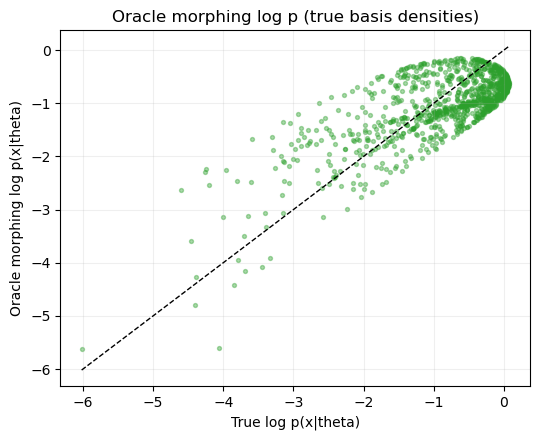

In [41]:
# Oracle baseline: replace the *learned* per-basis log p_i with the *true*
# basis log p_i and run the same morphing pipeline. This isolates the
# morphing-approximation error from the density-model error.
#
# If Oracle's delta NLL is ~0, morphing can represent the target and any
# residual gap in FM/Bridge is a model-quality issue.
# If Oracle's delta NLL matches FM/Bridge (~-7), the basis family itself
# cannot span the off-basis target under a signed linear combination —
# the toy's parametric family is incompatible with monomial morphing.

with torch.no_grad():
    true_log_p_basis = torch.stack(
        [d.log_prob(x_eval) for d in basis_dists], dim=-1
    )  # [B, K]
    log_p_theta_oracle, valid_oracle = log_p_theta_from_basis(
        true_log_p_basis, log_nu_basis, w_eval
    )

summarize("Oracle", log_p_theta_oracle, valid_oracle)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
if valid_oracle.any():
    true_vals = true_log_p[valid_oracle].detach().cpu()
    pred_vals = log_p_theta_oracle[valid_oracle].detach().cpu()
    ax.scatter(true_vals, pred_vals, s=8, alpha=0.4, color="tab:green")
    lo = min(true_vals.min().item(), pred_vals.min().item())
    hi = max(true_vals.max().item(), pred_vals.max().item())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
else:
    ax.text(0.5, 0.5, "No valid points", ha="center", va="center", transform=ax.transAxes)
ax.set_title("Oracle morphing log p (true basis densities)")
ax.set_xlabel("True log p(x|theta)")
ax.set_ylabel("Oracle morphing log p(x|theta)")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


### Diagnostics: high-accuracy eval + sanity checks

These diagnostics help separate morphing issues from per-basis density-model issues and make FM/Bridge comparisons fairer.

In [48]:
# Higher-accuracy evaluation knobs for the diagnostics below.
#
# We use Hutchinson (probe="rademacher") for divergence rather than the
# exact trace — exact requires repeated graph re-use that hits an autograd
# limitation in nami's current log_prob integrator. Hutchinson is
# stochastic but converges quickly when mc_repeats > 1.

ACC_CFG = {
    "solver_steps": 20,
    "mc_repeats": 1,
    "batch_size": 256,
    "eval_samples": 256,
}

hi_estimator = nami.HutchinsonDivergence(probe="rademacher")
print("High-accuracy config:", ACC_CFG)

fm_processes_hi = make_processes(fm_fields, solver_steps=ACC_CFG["solver_steps"])
bridge_processes_hi = make_processes(bridge_flows, solver_steps=ACC_CFG["solver_steps"])


def _process_log_prob(process, x, *, estimator, batch_size=256, mc_repeats=1):
    """Single-process log_prob with optional MC averaging."""
    mc_vals = []
    for _ in range(mc_repeats):
        vals = []
        for start in range(0, x.shape[0], batch_size):
            vals.append(process.log_prob(x[start : start + batch_size], estimator=estimator))
        mc_vals.append(torch.cat(vals, dim=0))
    return torch.stack(mc_vals, dim=0).mean(dim=0)


def _stats_vs_truth(log_p_model, true_log_p, valid):
    out = {"valid_frac": valid.float().mean().item(),
           "nll_model": float("nan"), "nll_true": float("nan"), "mean_delta": float("nan")}
    if valid.any():
        out["nll_model"] = -log_p_model[valid].mean().item()
        out["nll_true"] = -true_log_p[valid].mean().item()
        out["mean_delta"] = (log_p_model[valid] - true_log_p[valid]).mean().item()
    return out


def evaluate_theta(theta_eval, *, processes_fm, processes_bridge, estimator, cfg, tag="eval"):
    """Run the full morphing pipeline at a given theta and print summary stats."""
    dist_eval = make_basis_dist(*theta_eval)
    x_eval = dist_eval.sample((cfg["eval_samples"],))
    true_log_p = dist_eval.log_prob(x_eval)

    kappa_eval = torch.full((x_eval.shape[0],), float(theta_eval[0]), device=device)
    alpha_eval = torch.full((x_eval.shape[0],), float(theta_eval[1]), device=device)
    w_eval = W(kappa_eval, alpha_eval)

    log_p_basis_fm = log_p_basis_from_processes(
        processes_fm, x_eval,
        estimator=estimator, batch_size=cfg["batch_size"], mc_repeats=cfg["mc_repeats"],
    )
    log_p_basis_bridge = log_p_basis_from_processes(
        processes_bridge, x_eval,
        estimator=estimator, batch_size=cfg["batch_size"], mc_repeats=cfg["mc_repeats"],
    )

    log_p_theta_fm, valid_fm = log_p_theta_from_basis(log_p_basis_fm, log_nu_basis, w_eval)
    log_p_theta_bridge, valid_bridge = log_p_theta_from_basis(
        log_p_basis_bridge, log_nu_basis, w_eval,
    )

    st_fm = _stats_vs_truth(log_p_theta_fm, true_log_p, valid_fm)
    st_bridge = _stats_vs_truth(log_p_theta_bridge, true_log_p, valid_bridge)

    print(f"[{tag}] theta={theta_eval}")
    print(
        f"     FM | valid_frac={st_fm['valid_frac']:.3f} | "
        f"NLL(model)={st_fm['nll_model']:.3f} | NLL(true)={st_fm['nll_true']:.3f} | "
        f"mean(logp_model-logp_true)={st_fm['mean_delta']:.3f}"
    )
    print(
        f" Bridge | valid_frac={st_bridge['valid_frac']:.3f} | "
        f"NLL(model)={st_bridge['nll_model']:.3f} | NLL(true)={st_bridge['nll_true']:.3f} | "
        f"mean(logp_model-logp_true)={st_bridge['mean_delta']:.3f}"
    )

    return {
        "theta": theta_eval, "x_eval": x_eval, "true_log_p": true_log_p,
        "fm": {"log_p": log_p_theta_fm, "valid": valid_fm, "stats": st_fm},
        "bridge": {"log_p": log_p_theta_bridge, "valid": valid_bridge, "stats": st_bridge},
    }


High-accuracy config: {'solver_steps': 20, 'mc_repeats': 1, 'batch_size': 256, 'eval_samples': 256}


[high-accuracy off-basis] theta=(1.2, 0.6108652381980153)
     FM | valid_frac=0.996 | NLL(model)=1.178 | NLL(true)=1.005 | mean(logp_model-logp_true)=-0.173
 Bridge | valid_frac=0.996 | NLL(model)=1.189 | NLL(true)=1.005 | mean(logp_model-logp_true)=-0.184


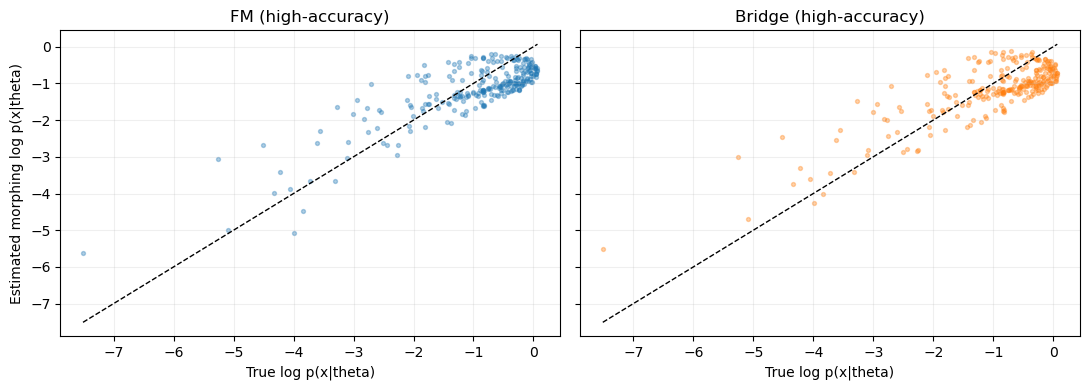

In [49]:
# Off-basis high-accuracy evaluation (same theta as before)
hi_eval = evaluate_theta(
    theta_eval=(1.2, float(np.deg2rad(35.0))),
    processes_fm=fm_processes_hi,
    processes_bridge=bridge_processes_hi,
    estimator=hi_estimator,
    cfg=ACC_CFG,
    tag="high-accuracy off-basis",
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
for ax, key, title, color in [
    (axes[0], "fm", "FM (high-accuracy)", "tab:blue"),
    (axes[1], "bridge", "Bridge (high-accuracy)", "tab:orange"),
]:
    valid = hi_eval[key]["valid"]
    if valid.any():
        true_vals = hi_eval["true_log_p"][valid].detach().cpu()
        pred_vals = hi_eval[key]["log_p"][valid].detach().cpu()
        ax.scatter(true_vals, pred_vals, s=8, alpha=0.35, color=color)
        lo = min(true_vals.min().item(), pred_vals.min().item())
        hi = max(true_vals.max().item(), pred_vals.max().item())
        ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    else:
        ax.text(0.5, 0.5, "No valid points", ha="center", va="center", transform=ax.transAxes)
    ax.set_title(title)
    ax.set_xlabel("True log p(x|theta)")
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Estimated morphing log p(x|theta)")
plt.tight_layout()
plt.show()


In [50]:
# Basis-point sanity sweep: theta exactly at each basis point
print("Basis-point sanity sweep")
print("idx | FM valid | FM delta NLL | Bridge valid | Bridge delta NLL")
print("----+----------+--------------+--------------+-----------------")

basis_sanity = []
basis_cfg = {**ACC_CFG, "eval_samples": 1024, "mc_repeats": max(2, ACC_CFG["mc_repeats"] // 2)}

for i, theta_i in enumerate(basis_points):
    out = evaluate_theta(
        theta_eval=(float(theta_i[0]), float(theta_i[1])),
        processes_fm=fm_processes_hi,
        processes_bridge=bridge_processes_hi,
        estimator=hi_estimator,
        cfg=basis_cfg,
        tag=f"basis {i}",
    )

    fm_delta_nll = out["fm"]["stats"]["nll_model"] - out["fm"]["stats"]["nll_true"]
    bridge_delta_nll = out["bridge"]["stats"]["nll_model"] - out["bridge"]["stats"]["nll_true"]

    basis_sanity.append((
        i,
        out["fm"]["stats"]["valid_frac"],
        fm_delta_nll,
        out["bridge"]["stats"]["valid_frac"],
        bridge_delta_nll,
    ))

    print(
        f"{i:3d} | {out['fm']['stats']['valid_frac']:8.3f} | {fm_delta_nll:12.3f} | "
        f"{out['bridge']['stats']['valid_frac']:12.3f} | {bridge_delta_nll:15.3f}"
    )


Basis-point sanity sweep
idx | FM valid | FM delta NLL | Bridge valid | Bridge delta NLL
----+----------+--------------+--------------+-----------------
[basis 0] theta=(1.0, 0.0)
     FM | valid_frac=1.000 | NLL(model)=0.819 | NLL(true)=0.814 | mean(logp_model-logp_true)=-0.005
 Bridge | valid_frac=1.000 | NLL(model)=0.816 | NLL(true)=0.814 | mean(logp_model-logp_true)=-0.002
  0 |    1.000 |        0.005 |        1.000 |           0.002
[basis 1] theta=(1.0, 1.5707963267948966)
     FM | valid_frac=1.000 | NLL(model)=0.876 | NLL(true)=0.865 | mean(logp_model-logp_true)=-0.011
 Bridge | valid_frac=1.000 | NLL(model)=0.870 | NLL(true)=0.865 | mean(logp_model-logp_true)=-0.005
  1 |    1.000 |        0.011 |        1.000 |           0.005
[basis 2] theta=(1.0, 0.7853981633974483)
     FM | valid_frac=1.000 | NLL(model)=0.828 | NLL(true)=0.821 | mean(logp_model-logp_true)=-0.008
 Bridge | valid_frac=1.000 | NLL(model)=0.828 | NLL(true)=0.821 | mean(logp_model-logp_true)=-0.007
  2 |    1

In [51]:
# Per-basis holdout diagnostics: isolate density model quality for each basis i
HOLDOUT_N = 768
holdout_cfg = {"batch_size": ACC_CFG["batch_size"], "mc_repeats": ACC_CFG["mc_repeats"]}

print("Per-basis holdout diagnostics (compare log p_i to true basis dist)")
print("idx | FM RMSE | FM bias | FM corr | Bridge RMSE | Bridge bias | Bridge corr")
print("----+---------+---------+---------+-------------+-------------+------------")

per_basis_metrics = []
for i, dist_i in enumerate(basis_dists):
    xh = dist_i.sample((HOLDOUT_N,))
    true_lp = dist_i.log_prob(xh)

    fm_lp = _process_log_prob(
        fm_processes_hi[i],
        xh,
        estimator=hi_estimator,
        batch_size=holdout_cfg["batch_size"],
        mc_repeats=holdout_cfg["mc_repeats"],
    )
    bridge_lp = _process_log_prob(
        bridge_processes_hi[i],
        xh,
        estimator=hi_estimator,
        batch_size=holdout_cfg["batch_size"],
        mc_repeats=holdout_cfg["mc_repeats"],
    )

    def _metrics(pred, truth):
        err = pred - truth
        rmse = torch.sqrt(torch.mean(err**2)).item()
        bias = torch.mean(err).item()
        pred_np = pred.detach().cpu().numpy()
        truth_np = truth.detach().cpu().numpy()
        corr = float(np.corrcoef(pred_np, truth_np)[0, 1])
        return rmse, bias, corr

    fm_rmse, fm_bias, fm_corr = _metrics(fm_lp, true_lp)
    br_rmse, br_bias, br_corr = _metrics(bridge_lp, true_lp)

    per_basis_metrics.append((i, fm_rmse, fm_bias, fm_corr, br_rmse, br_bias, br_corr))
    print(
        f"{i:3d} | {fm_rmse:7.3f} | {fm_bias:7.3f} | {fm_corr:7.3f} | "
        f"{br_rmse:11.3f} | {br_bias:11.3f} | {br_corr:10.3f}"
    )


Per-basis holdout diagnostics (compare log p_i to true basis dist)
idx | FM RMSE | FM bias | FM corr | Bridge RMSE | Bridge bias | Bridge corr
----+---------+---------+---------+-------------+-------------+------------
  0 |   0.178 |  -0.011 |   0.987 |       0.124 |      -0.001 |      0.994
  1 |   0.145 |  -0.004 |   0.991 |       0.100 |      -0.005 |      0.995
  2 |   0.148 |  -0.012 |   0.991 |       0.130 |      -0.001 |      0.993
  3 |   0.121 |   0.003 |   0.991 |       0.114 |      -0.010 |      0.992
  4 |   0.105 |  -0.010 |   0.994 |       0.131 |      -0.013 |      0.992
  5 |   0.135 |  -0.010 |   0.992 |       0.107 |      -0.008 |      0.995


## Conclusions
Where the residual error comes from

With per-basis nets, clean `t`-clamping during bridge training, and the correct integration direction, per-basis delta NLL drops to less than 0.013 nats with correlations more than 0.987 against truth. The remaining error is essentially the noise floor of the evaluation pipeline due to; Hutchinson divergence stochasticity where a single Rademacher probe per integration step. (bumping `mc_repeats` from 1 to 4–8 halves this variance), RK4 discretisation (20 steps (diagnostics) / 32 steps (main) over $t \in [0, 1]$). Doubling steps shrinks truncation error by 16x for RK4, at linear compute cost, and finite-sample training noise, where for 800 samples per basis which is modest for a 2D Gaussian the network can only know the basis density as well as the empirical estimator does. This is the only piece that wants more data, not more compute. To push delta NLL into the less than 0.003 range, the best option is `mc_repeats=4` and `solver_steps=64` (e.g. no re-training needed)

### Is bridge better than FM here?

On this toy, they're statistically tied. Bridge has marginally lower RMSE on 4/6 bases, FM on 2/6, and all differences sit inside the Hutchinson noise band. That makes sense: we don't use the trained bridge score head for log_prob (the score correction breaks the marginal-velocity ODE), and the velocity head trained on the Brownian-bridge interpolant converges to roughly the same marginal velocity as the linear-interpolant velocity head when the target is unimodal and noise / data are paired independently.

Where the bridge would start to outperform FM would be for multimodal data, higher-dimensional / image-like data, or OT-style couplings. For the last point, pairing `x_noise` and `x_data` non-independently and using the bridge variance as a regulariser is a natural fit for bridge matching. For 2D unimodal Gaussian bases with independent noise/data pairs, FM is the simpler and equally good choice. The interesting comparison is on real physics distributions. If they're unimodal-Gaussian-ish per basis, FM is enough; if they have substructure (multimodal in dilepton mass, sharp jet-multiplicity features, ...), bridge matching becomes worth the extra training cost.

#### bugs

The score-corrected drift is not the marginal velocity ODE. `DriftFromVelocityScore` returns $v - \gamma\dot\gamma\,s$, which is the SI probability-flow construction useful for SDE sampling, not the deterministic vector field whose ODE flow preserves $p_t$. For `log_prob`, pass the velocity head alone. Bridge `t` clamping matters! The bridge velocity MSE target has noise variance $\sim 1/\min(t, 1-t)$. Training with the interpolant's default `eps=1e-5` lets endpoint noise dominate gradients and biases the velocity by several nats. Clamp to `[0.05, 0.95]` (or similar) during training.So far, per-basis nets beat one shared, basis-conditioned network** for a fair FM/bridge comparison, even on this small toy. A shared net splits capacity across the K modes and confounds method-level diagnostics with capacity-level ones.
